In [8]:
"""
Part 1: Load FBref data for both training seasons, clean and engineer features.

Inputs:
  - premier-player-23-24__1_.csv   (FBref standard stats, 2023/24)
  - fbref_PL_2024-25__1_.csv       (FBref standard stats, 2024/25)

Output:
  - df_all.pkl   (combined, cleaned, feature-engineered dataframe)
"""

import pandas as pd
import numpy as np

# -----------------------------------------------------------------------
# 1. Load and standardise both seasons
# -----------------------------------------------------------------------
df2324 = pd.read_csv("premier-player-23-24.csv")
df2425 = pd.read_csv("fbref_PL_2024-25.csv")

# 2023/24 uses different per-90 column names — standardise to 2024/25 schema
df2324 = df2324.rename(columns={
    "Gls_90": "Gls.1",
    "Ast_90": "Ast.1",
    "npxG_90": "npxG.1",
    "xAG_90": "xAG.1",
    "Team": "Squad",
})
df2324["Season"] = "2023/24"
df2425["Season"] = "2024/25"

common_cols = ["Player","Squad","Pos","Age","MP","Min","90s",
               "Gls","Gls.1","Ast.1","npxG.1","xAG.1",
               "PrgC","PrgP","PrgR","Season"]

df = pd.concat([df2324[common_cols], df2425[common_cols]], ignore_index=True)

# -----------------------------------------------------------------------
# 2. Clean and filter
# -----------------------------------------------------------------------
for col in ["Min","Age","Gls","Gls.1","Ast.1","npxG.1","xAG.1",
            "PrgC","PrgP","PrgR","90s","MP"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Attackers only (FW primary or secondary position), 900+ minutes
df = df[df["Pos"].str.contains("FW", na=False)]
df = df[df["Min"] >= 900]
df = df.dropna(subset=["Min","Age","Gls.1","Ast.1","npxG.1","xAG.1",
                        "PrgC","PrgP","PrgR","90s","MP"])
df = df.reset_index(drop=True)

print(f"Total attacker-seasons: {len(df)}")
print(df["Season"].value_counts())

# -----------------------------------------------------------------------
# 3. Engineer features
# -----------------------------------------------------------------------
df["PrgC_90"]       = df["PrgC"] / df["90s"]    # progressive carries per 90
df["PrgR_90"]       = df["PrgR"] / df["90s"]    # progressive receptions per 90
df["min_per_game"]  = df["Min"]  / df["MP"]     # manager trust / fitness proxy
df["age_sq"]        = df["Age"]  ** 2           # nonlinear age curve
df["goal_diff"]     = df["Gls.1"] - df["npxG.1"]  # over/underperformance vs xG

# -----------------------------------------------------------------------
# 4. Define TARGET: npxG per 90 tier within each season
#    Tiers are set by percentile rank WITHIN season (avoids cross-season drift)
#    This is cleanly separate from the model features
# -----------------------------------------------------------------------
df["npxG_pct"] = df.groupby("Season")["npxG.1"].rank(pct=True) * 100

def goal_threat_tier(pct):
    if pct >= 80:    return "Elite"
    elif pct >= 55:  return "Strong"
    elif pct >= 25:  return "Moderate"
    else:             return "Low"

df["GoalThreat"] = df["npxG_pct"].apply(goal_threat_tier)

print("\nGoal threat tier distribution per season:")
print(df.groupby(["Season","GoalThreat"]).size().unstack(fill_value=0))

df.to_pickle("df_all.pkl")
print("\nSaved df_all.pkl")

Total attacker-seasons: 212
Season
2023/24    109
2024/25    103
Name: count, dtype: int64

Goal threat tier distribution per season:
GoalThreat  Elite  Low  Moderate  Strong
Season                                  
2023/24        20   27        33      29
2024/25        20   26        31      26

Saved df_all.pkl


In [9]:
"""
Part 2: Train ordered logistic regression on 2023/24, test on 2024/25.

Target:   npxG per 90 tier — Low / Moderate / Strong / Elite
          Defined by percentile rank WITHIN each season (Part 1)
          Cleanly separate from model features (no circular dependency)

Features: actual goals, assists, xAG, progressive carries/receptions,
          goal over/underperformance, age, age squared, minutes per game

Model:    Ordered logit (statsmodels OrderedModel)
          Appropriate because tiers are genuinely ordered: Low < Moderate
          < Strong < Elite — one latent "goal threat" axis with cut-points

Split:    Temporal — train on 2023/24, test on 2024/25 (strictly unseen)
"""

import pandas as pd
import numpy as np
import pickle
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report)

df = pd.read_pickle("df_all.pkl")

FEATURES = [
    "Gls.1",        # actual goals per 90 — independent of npxG target
    "Ast.1",        # actual assists per 90
    "xAG.1",        # expected assisted goals per 90 (chance creation)
    "PrgC_90",      # progressive carries per 90
    "PrgR_90",      # progressive receptions per 90 (movement)
    "goal_diff",    # goals minus npxG (finisher quality signal)
    "Age",          # age
    "age_sq",       # nonlinear age curve
    "min_per_game", # manager trust / fitness
]
TARGET_ORDER = ["Low","Moderate","Strong","Elite"]

# Temporal train/test split
train = df[df["Season"] == "2023/24"].copy().reset_index(drop=True)
test  = df[df["Season"] == "2024/25"].copy().reset_index(drop=True)

print(f"Train rows: {len(train)}  |  Test rows: {len(test)}")

# Standardise features (ordered logit sensitive to scale)
scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(train[FEATURES]), columns=FEATURES)
X_test  = pd.DataFrame(scaler.transform(test[FEATURES]),      columns=FEATURES)

# Encode target as ordered categorical (statsmodels requires Series)
train["GoalThreat_ord"] = pd.Categorical(
    train["GoalThreat"], categories=TARGET_ORDER, ordered=True)

# Fit
model  = OrderedModel(train["GoalThreat_ord"], X_train, distr="logit")
result = model.fit(method="bfgs", disp=False)

print("\n--- Model summary ---")
print(result.summary())

# Evaluate
pred_test  = result.predict(X_test)
y_pred     = [TARGET_ORDER[i] for i in pred_test.values.argmax(axis=1)]
test_acc   = accuracy_score(test["GoalThreat"], y_pred)
most_common = train["GoalThreat"].value_counts().idxmax()
baseline   = accuracy_score(test["GoalThreat"], [most_common]*len(test))

print(f"\nStrict test accuracy (train 23/24 → predict 24/25): {test_acc:.3f}")
print(f"Naive baseline (always '{most_common}'):              {baseline:.3f}")

print("\nConfusion matrix (rows=actual, cols=predicted):")
print(pd.DataFrame(
    confusion_matrix(test["GoalThreat"], y_pred, labels=TARGET_ORDER),
    index=TARGET_ORDER, columns=TARGET_ORDER))

print("\nClassification report:")
print(classification_report(test["GoalThreat"], y_pred,
                             labels=TARGET_ORDER, zero_division=0))

# Save
with open("ordinal_model.pkl","wb") as f:
    pickle.dump({"result": result, "scaler": scaler,
                 "features": FEATURES, "target_order": TARGET_ORDER}, f)
print("Saved ordinal_model.pkl")

Train rows: 109  |  Test rows: 103

--- Model summary ---
                             OrderedModel Results                             
Dep. Variable:         GoalThreat_ord   Log-Likelihood:            -3.8380e-05
Model:                   OrderedModel   AIC:                             24.00
Method:            Maximum Likelihood   BIC:                             56.30
Date:                Sun, 26 Jul 2026                                         
Time:                        18:58:37                                         
No. Observations:                 109                                         
Df Residuals:                      97                                         
Df Model:                           9                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Gls.1             541.0711   1.83e+04      0.030      0.976   -

In [10]:
"""
Part 3: Retrain on BOTH seasons combined, then predict 2025/26 goal threat.

Why retrain on both seasons?
  Part 2 used only 2023/24 to train — that was the cross-season validation.
  Now we use all available labelled data (2023/24 + 2024/25) for the best
  possible 2025/26 predictions.

Key fix: internal EPL transfers are applied BEFORE any squad-based filtering.
  Without this, players like Cunha (Wolves→Man Utd) and Delap (Ipswich→Chelsea)
  would be incorrectly excluded because their old clubs are filtered out.

Transfers applied:
  Left EPL: Jota (deceased), Díaz (Bayern Munich), Núñez (Al-Hilal),
            Jackson (Bayern loan), Nkunku (AC Milan),
            Rashford (Barcelona loan), Højlund (Napoli loan),
            Son (LAFC), De Bruyne (Napoli), Bailey (Roma loan),
            Guedes (Real Sociedad)

  Internal EPL moves (new squad assigned FIRST):
    Mbeumo, Cunha       → Manchester Utd
    Garnacho            → Chelsea
    Madueke, Eze        → Arsenal
    Isak                → Liverpool
    Wissa, Elanga, Ramsey → Newcastle Utd
    Kudus               → Tottenham
    Ouattara            → Brentford
    Adingra             → Sunderland  [then excluded — no EPL squad data]
    Calvert-Lewin       → Leeds
    João Pedro, Delap   → Chelsea
    Dibling             → Everton
    Sancho              → Aston Villa (loan)

  Excluded clubs (no 2024/25 EPL attacker data):
    Coventry, Hull, Sunderland, Wolves

  2024/25 relegated clubs (not in EPL 2025/26):
    Southampton, Leicester City, Ipswich Town
"""

import pandas as pd
import numpy as np
import pickle
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.preprocessing import StandardScaler

df = pd.read_pickle("df_all.pkl")

FEATURES     = ["Gls.1","Ast.1","xAG.1","PrgC_90","PrgR_90",
                "goal_diff","Age","age_sq","min_per_game"]
TARGET_ORDER = ["Low","Moderate","Strong","Elite"]

# -----------------------------------------------------------------------
# Train on BOTH seasons
# -----------------------------------------------------------------------
train = df.copy().reset_index(drop=True)
train["GoalThreat_ord"] = pd.Categorical(
    train["GoalThreat"], categories=TARGET_ORDER, ordered=True)

scaler  = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(train[FEATURES]), columns=FEATURES)

model  = OrderedModel(train["GoalThreat_ord"], X_train, distr="logit")
result = model.fit(method="bfgs", disp=False)
print(f"Training rows (2023/24 + 2024/25): {len(train)}")

# -----------------------------------------------------------------------
# Build 2025/26 prediction input
# CRITICAL: apply transfer moves BEFORE filtering by squad
# -----------------------------------------------------------------------
predict_input = df[df["Season"] == "2024/25"].copy().reset_index(drop=True)

# Step 1: Apply internal EPL moves FIRST
internal_moves = {
    "Bryan Mbeumo":          "Manchester Utd",
    "Matheus Cunha":         "Manchester Utd",   # Wolves → Man Utd
    "Alejandro Garnacho":    "Chelsea",
    "Noni Madueke":          "Arsenal",
    "Eberechi Eze":          "Arsenal",
    "Alexander Isak":        "Liverpool",
    "Yoane Wissa":           "Newcastle Utd",
    "Anthony Elanga":        "Newcastle Utd",
    "Jacob Ramsey":          "Newcastle Utd",
    "Jadon Sancho":          "Aston Villa",
    "Mohammed Kudus":        "Tottenham",
    "Dango Ouattara":        "Brentford",
    "Simon Adingra":         "Sunderland",       # Brighton → Sunderland
    "Dominic Calvert-Lewin": "Leeds",
    "João Pedro":            "Chelsea",
    "Joao Pedro":            "Chelsea",
    "Liam Delap":            "Chelsea",           # Ipswich → Chelsea
    "Tyler Dibling":         "Everton",
}
predict_input["Squad"] = predict_input.apply(
    lambda r: internal_moves.get(r["Player"], r["Squad"]), axis=1)

# Step 2: Remove players who left EPL entirely
left_epl = [
    "Diogo Jota",
    "Luis Díaz", "Luis Diaz",
    "Darwin Núñez",
    "Nicolas Jackson",
    "Christopher Nkunku",
    "Marcus Rashford",
    "Rasmus Hojlund", "Rasmus Højlund",
    "Son Heung-min",
    "Kevin De Bruyne",
    "Leon Bailey",
    "Goncalo Guedes",
]
predict_input = predict_input[~predict_input["Player"].isin(left_epl)]

# Step 3: Remove players whose UPDATED squad is excluded or relegated
# (Adingra → Sunderland → excluded; Delap/Cunha → EPL clubs → kept)
excluded_clubs  = ["Sunderland", "Wolves"]
relegated_2425  = ["Southampton", "Leicester City", "Ipswich Town"]

predict_input = predict_input[
    ~predict_input["Squad"].isin(excluded_clubs + relegated_2425)
].reset_index(drop=True)

print(f"Players in 2025/26 predictions: {len(predict_input)}")
print(f"Squads: {sorted(predict_input['Squad'].unique())}")

# -----------------------------------------------------------------------
# Predict
# -----------------------------------------------------------------------
X_pred = pd.DataFrame(scaler.transform(predict_input[FEATURES]), columns=FEATURES)
proba  = result.predict(X_pred)
proba.columns = TARGET_ORDER

predict_input = pd.concat([
    predict_input.reset_index(drop=True),
    proba.round(3).reset_index(drop=True)
], axis=1)
predict_input["Predicted_2526"] = [
    TARGET_ORDER[i] for i in proba.values.argmax(axis=1)]

predict_input = predict_input.sort_values("Elite", ascending=False).reset_index(drop=True)

print("\n2025/26 predictions (top 20):")
print(predict_input.head(20)[["Player","Squad","npxG.1",
                               "GoalThreat","Predicted_2526",
                               "Elite","Strong"]].to_string(index=False))

predict_input.to_csv("attacker_goal_threat_2526.csv", index=False)
with open("ordinal_model_final.pkl","wb") as f:
    pickle.dump({"result": result, "scaler": scaler,
                 "features": FEATURES, "target_order": TARGET_ORDER}, f)
print("\nSaved attacker_goal_threat_2526.csv and ordinal_model_final.pkl")

Training rows (2023/24 + 2024/25): 212
Players in 2025/26 predictions: 74
Squads: ['Arsenal', 'Aston Villa', 'Bournemouth', 'Brentford', 'Brighton', 'Chelsea', 'Crystal Palace', 'Everton', 'Fulham', 'Leeds', 'Liverpool', 'Manchester City', 'Manchester Utd', 'Newcastle Utd', "Nott'ham Forest", 'Tottenham', 'West Ham']

2025/26 predictions (top 20):
               Player           Squad  npxG.1 GoalThreat Predicted_2526  Elite  Strong
          Kai Havertz         Arsenal    0.46      Elite          Elite  1.000   0.000
        Ollie Watkins     Aston Villa    0.48      Elite          Elite  1.000   0.000
                 Beto         Everton    0.48      Elite          Elite  1.000   0.000
        Eddie Nketiah  Crystal Palace    0.50      Elite          Elite  1.000   0.000
        Mohamed Salah       Liverpool    0.49      Elite          Elite  1.000   0.000
       Alexander Isak       Liverpool    0.56      Elite          Elite  1.000   0.000
       Erling Haaland Manchester City    

Saved attacker_goal_threat_2526.png


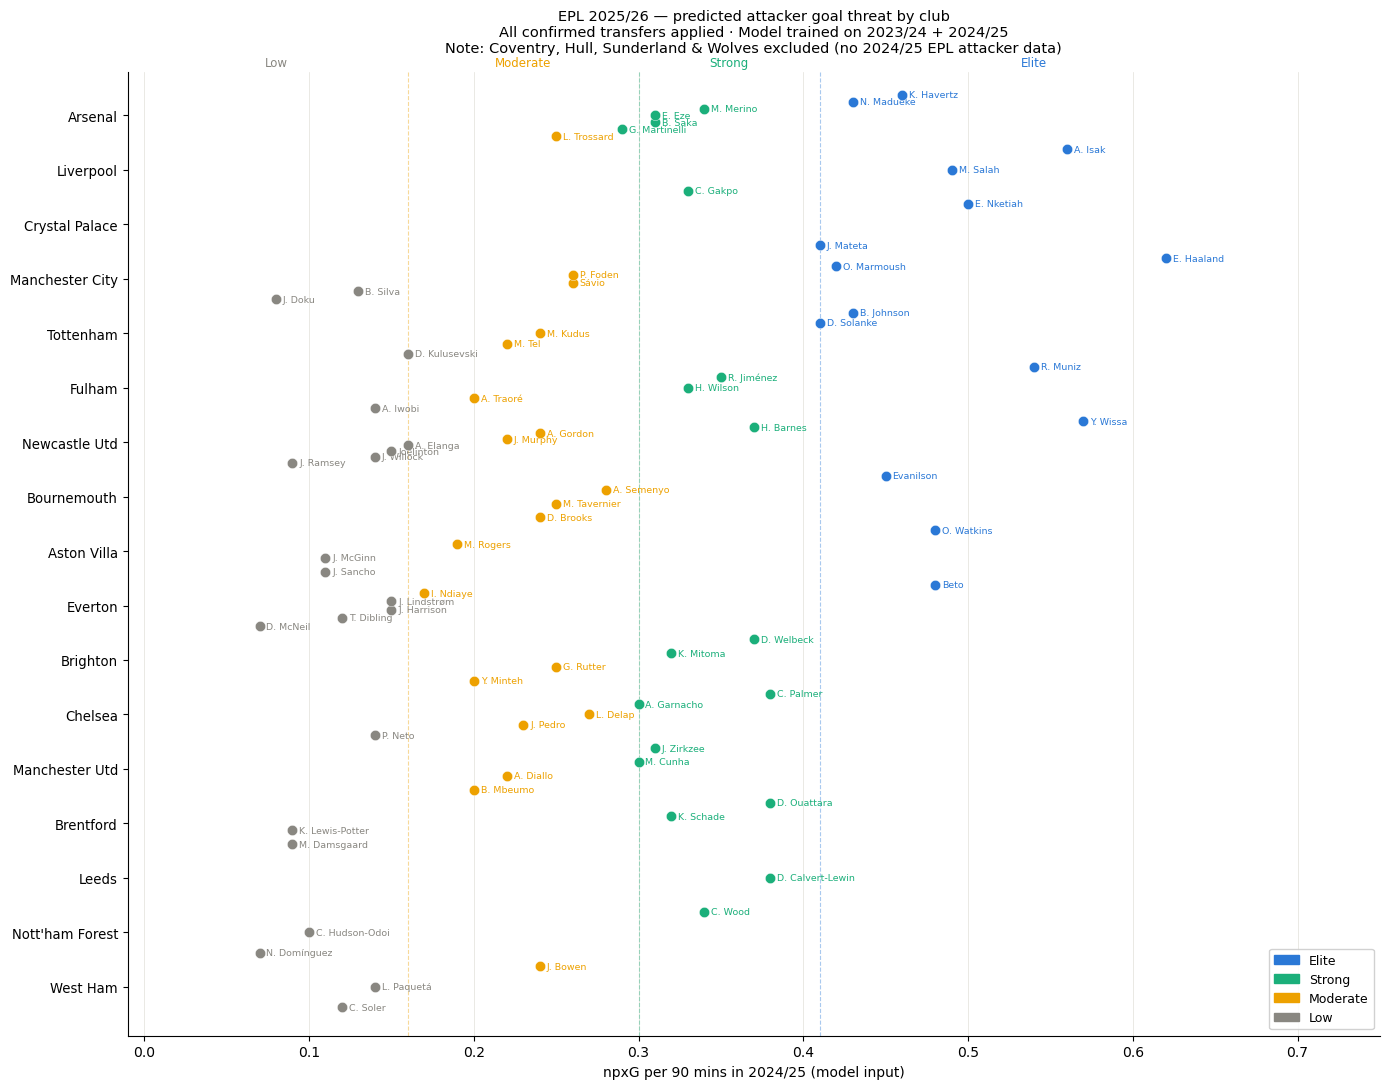

In [11]:
"""
Part 4: Visualise 2025/26 predicted attacker goal threat by club.

Chart type: dot plot, one dot per player per club, labelled with
first initial + surname, coloured by predicted tier, x-axis = npxG/90.

Excluded from chart (no 2024/25 EPL attacker data):
  Coventry, Hull, Sunderland, Wolves
"""

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

df = pd.read_csv("attacker_goal_threat_2526.csv")

tier_color = {
    "Elite":    "#2a78d6",
    "Strong":   "#1baf7a",
    "Moderate": "#eda100",
    "Low":      "#898781",
}
tier_order = ["Elite","Strong","Moderate","Low"]

# Sort squads: most Elite at top, then Strong, then avg npxG
squad_rank = (df.assign(
    elite_flag=(df["Predicted_2526"]=="Elite").astype(int),
    strong_flag=(df["Predicted_2526"]=="Strong").astype(int),
).groupby("Squad").agg(
    elite=("elite_flag","sum"),
    strong=("strong_flag","sum"),
    avg_npxg=("npxG.1","mean"),
).sort_values(["elite","strong","avg_npxg"], ascending=True))

squads = squad_rank.index.tolist()
squad_y = {s: i for i, s in enumerate(squads)}

# Shorten names for labels
def short_name(name):
    parts = name.split()
    if len(parts) == 1:
        return name
    return parts[0][0] + ". " + parts[-1]

df["label"] = df["Player"].apply(short_name)
df = df.sort_values(["Squad","npxG.1"], ascending=[True,True]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 11))

for squad in squads:
    squad_df = df[df["Squad"]==squad].reset_index(drop=True)
    n = len(squad_df)
    offsets = np.linspace(-0.38, 0.38, n) if n > 1 else [0]
    y_base = squad_y[squad]

    for idx, (_, row) in enumerate(squad_df.iterrows()):
        y = y_base + offsets[idx]
        color = tier_color[row["Predicted_2526"]]
        ax.scatter(row["npxG.1"], y, color=color, s=55,
                   zorder=3, linewidths=0.3, edgecolors="white")
        ax.annotate(row["label"],
                    xy=(row["npxG.1"], y),
                    xytext=(5, 0), textcoords="offset points",
                    fontsize=6.8, color=color, va="center",
                    fontweight="medium")

# Tier boundary lines
for xval, color in [(0.41,"#2a78d6"),(0.30,"#1baf7a"),(0.16,"#eda100")]:
    ax.axvline(xval, color=color, linewidth=0.8, linestyle="--", alpha=0.4)

# Tier labels at top
for label, xc in [("Elite",0.54),("Strong",0.355),("Moderate",0.23),("Low",0.08)]:
    ax.text(xc, len(squads)-0.15, label, ha="center", va="bottom",
            fontsize=8.5, color=tier_color[label], fontweight="medium")

ax.set_yticks(range(len(squads)))
ax.set_yticklabels(squads, fontsize=9.5)
ax.set_xlabel("npxG per 90 mins in 2024/25 (model input)", fontsize=10)
ax.set_xlim(-0.01, 0.75)
ax.set_ylim(-0.9, len(squads) - 0.2)
ax.set_title(
    "EPL 2025/26 — predicted attacker goal threat by club\n"
    "All confirmed transfers applied · Model trained on 2023/24 + 2024/25\n"
    "Note: Coventry, Hull, Sunderland & Wolves excluded (no 2024/25 EPL attacker data)",
    fontsize=10.5, pad=14)

legend_patches = [mpatches.Patch(color=tier_color[t], label=t) for t in tier_order]
ax.legend(handles=legend_patches, loc="lower right",
          fontsize=9, frameon=True, framealpha=0.9)

ax.grid(axis="x", color="#e1e0d9", linewidth=0.5, zorder=0)
ax.set_axisbelow(True)
for spine in ["top","right"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig("attacker_goal_threat_2526.png", dpi=160, bbox_inches="tight")
print("Saved attacker_goal_threat_2526.png")